In [2]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette, set_plot_colors
import os
import seaborn as sns
import yaml

from autoslo.workload_execution.trace import Trace

parsed_plans_path = os.path.join(pu.get_data_path(), "parsed_query_plans", "ext_tpcds1000.yml")
with open(parsed_plans_path, "r") as f:
    plans = yaml.safe_load(f)

In [13]:
# For each plan, recursively find all table names used. The are fields called "table"
def extract_tables(plan_node):
    tables = set()
    plan_parameters = plan_node.get('plan_parameters', {})
    if 'table' in plan_parameters and not 'volt_tt' in plan_parameters['table']:
        tables.add(plan_parameters['table'])
    if 'children' in plan_node:
        for child in plan_node['children']:
            tables.update(extract_tables(child))
    return tables

tables_per_query = {}
for template_id, plan in plans.items():
    tables = extract_tables(plan)
    tables_per_query[template_id] = tables

In [ ]:
# Find the full set of tables across queries
all_tables = set()
for tables in tables_per_query.values():
    all_tables.update(tables)
all_tables = sorted(all_tables)
print(f"All tables ({len(all_tables)}) used across queries: {all_tables}")

All tables (24) used across queries: ['call_center', 'catalog_page', 'catalog_returns', 'catalog_sales', 'customer', 'customer_address', 'customer_demographics', 'date_dim', 'household_demographics', 'income_band', 'inventory', 'item', 'promotion', 'reason', 'ship_mode', 'store', 'store_returns', 'store_sales', 'time_dim', 'warehouse', 'web_page', 'web_returns', 'web_sales', 'web_site']


In [21]:
# Validate that all queries of the same template (same before the underscore) use the same set of tables
template_to_tables = {}
for temp_and_q_idx, tables in tables_per_query.items():
    template_id = int(temp_and_q_idx.split('_')[0])
    if template_id not in template_to_tables:
        template_to_tables[template_id] = tables
    else:
        # Superset
        template_to_tables[template_id].update(tables)

In [25]:
# Read in the light and the heavy templates
light_path = '/home/markakis/chunkbench/data/light_templates.txt'
heavy_path = '/home/markakis/chunkbench/data/heavy_templates.txt'

with open(light_path, 'r') as f:
    light_templates = {int(line.strip()) for line in f.readlines()}
with open(heavy_path, 'r') as f:
    heavy_templates = {int(line.strip()) for line in f.readlines()}

In [42]:
# Read in table stats
table_stats_path = '/home/markakis/chunkbench/data/db_stats/cluster_32_tpcds1000.yml'
with open(table_stats_path, 'r') as f:
    table_stats = yaml.safe_load(f)['table_stats']
num_rows_per_table = {table_stat['table_name']: table_stat['num_rows'] for table_stat in table_stats.values()}
num_rows_per_table_df = pd.DataFrame.from_dict(num_rows_per_table, orient='index', columns=['num_rows'])

# Don't show in scientific notation
pd.set_option('display.float_format', '{:,}'.format)
num_rows_per_table_df = num_rows_per_table_df.sort_values(by='num_rows', ascending=False)
num_rows_per_table_df

,num_rows
store_sales,"2,879,987,999.0"
catalog_sales,"1,439,980,416.0"
inventory,"783,000,000.0"
web_sales,"720,000,376.0"
store_returns,"287,999,764.0"
catalog_returns,"143,996,756.0"
web_returns,"71,997,522.0"
customer,"12,000,000.0"
customer_address,"6,000,000.0"
customer_demographics,"1,920,800.0"


In [43]:
table_size_sort_order = num_rows_per_table_df.index.tolist()

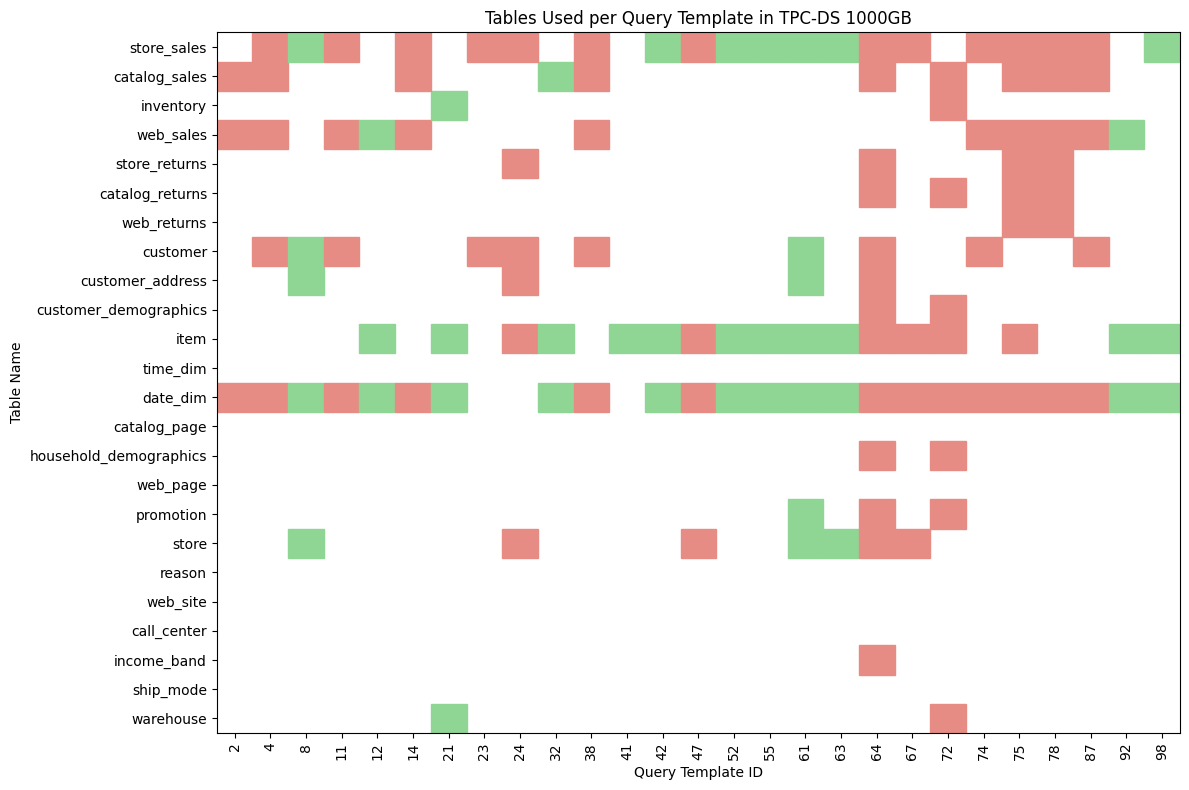

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
# Plot a heatmap where the x axis is template id, y axis is table name, and value is 1 if table is used in template, 0 otherwise
# Only plot the light and heavy templates, in separate colors, by having the template labels in different colors
template_to_tables_subset = {k: v for k, v in template_to_tables.items() if k in light_templates or k in heavy_templates}
heatmap_data = pd.DataFrame(0, index=reversed(table_size_sort_order), columns=sorted(template_to_tables_subset.keys()))

for template_id, tables in template_to_tables_subset.items():
    for table in tables:
        heatmap_data.at[table, template_id] = 1

plt.figure(figsize=(12, 8))

# Manually create the heatmap to have more control using Rectangles
ax = plt.gca()
for i, table in enumerate(heatmap_data.index):
    for j, template_id in enumerate(heatmap_data.columns):
        if heatmap_data.at[table, template_id] == 1:
            color = Palette.light_green if template_id in light_templates else Palette.light_red
            rect = Rectangle((j, i), 1, 1, color=color)
            ax.add_patch(rect)

ax.set_xticks(np.arange(len(heatmap_data.columns)) + 0.5)
ax.set_xticklabels(heatmap_data.columns, rotation=90)
ax.set_yticks(np.arange(len(heatmap_data.index)) + 0.5)
ax.set_yticklabels(heatmap_data.index)
plt.xlim(0, len(heatmap_data.columns))
plt.ylim(0, len(heatmap_data.index))


plt.xlabel('Query Template ID')
plt.ylabel('Table Name')
plt.title('Tables Used per Query Template in TPC-DS 1000GB')
plt.tight_layout()
plt.savefig('tables_per_query_template_heatmap.svg', bbox_inches='tight')
plt.show()

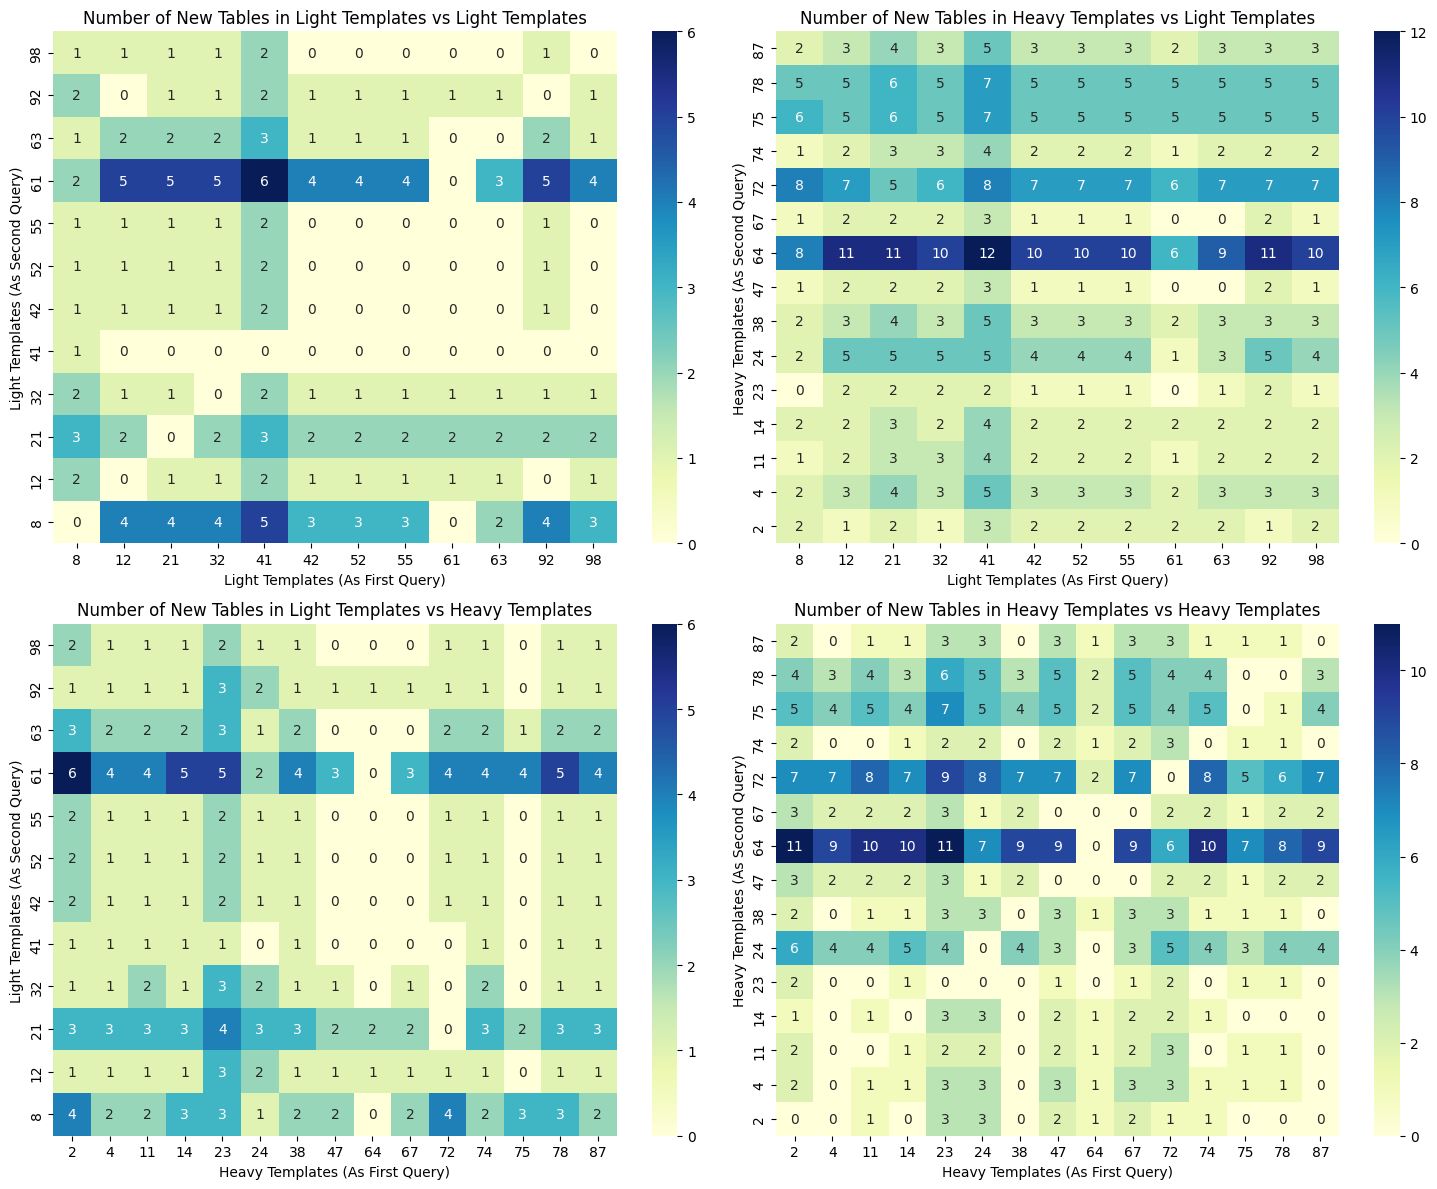

In [58]:
# Create 4 subplots in a 2x2 grid - one for (light, light), (light, heavy), (heavy, light), (heavy, heavy)
# In each subplot, have the x axis be the second template, y axis be the first template, 
# and plot a heatmap which is "number of tables used by second template that are not used by first template"

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
combinations = [('Light', 'Light', light_templates, light_templates),
                ('Light', 'Heavy', light_templates, heavy_templates),
                ('Heavy', 'Light', heavy_templates, light_templates),
                ('Heavy', 'Heavy', heavy_templates, heavy_templates)]   

for ax, (title_x, title_y, templates_x, templates_y) in zip(axs.flatten(), combinations):
    new_tables_matrix = pd.DataFrame(0, index=sorted(templates_y), columns=sorted(templates_x))
    for t_y in templates_y:
        tables_y = template_to_tables.get(t_y, set())
        for t_x in templates_x:
            tables_x = template_to_tables.get(t_x, set())
            new_tables = tables_y - tables_x
            new_tables_matrix.at[t_y, t_x] = len(new_tables)
    sns.heatmap(new_tables_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=ax)

    # Reverse y axis to have lower template ids at the bottom
    ax.invert_yaxis()
    ax.set_xlabel(f'{title_x} Templates (As First Query)')
    ax.set_ylabel(f'{title_y} Templates (As Second Query)')
    ax.set_title(f'Number of New Tables in {title_y} Templates vs {title_x} Templates')
plt.tight_layout()
plt.savefig('query_compliance.svg', bbox_inches='tight')
plt.show()


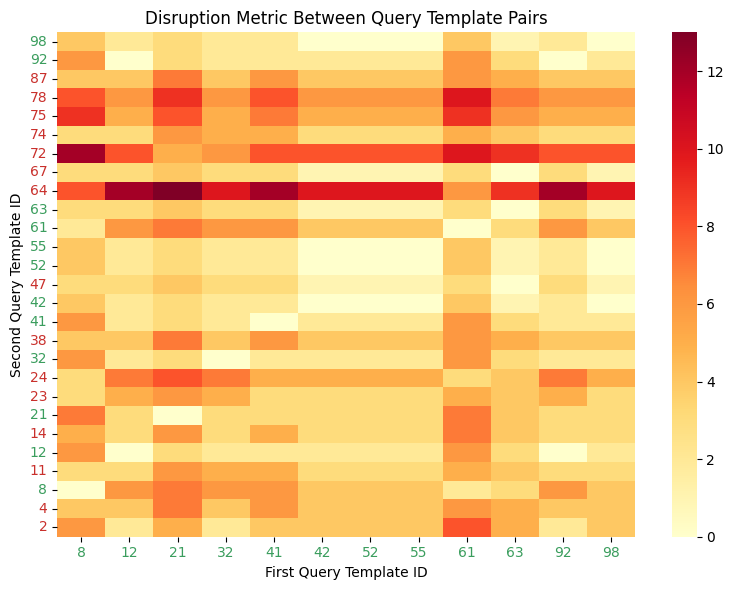

In [70]:
# For each combination of templates where the first is light and the second is light or heavy, 
# assume we execute Q1:first template -> Q2:second template -> Q3:first template again.
# Calculate a "disruption" metric as the number of new tables introduced by
# Q2 compared to Q1, plus the number of new tables introduced by Q3 compared to Q2.
# Plot as a heatmap similar to above. In the axis ticks, color the template ids
# according to whether they are light (green) or heavy (red).
disruption_fig, disruption_ax = plt.subplots(figsize=(8, 6))
disruption_matrix = pd.DataFrame(0, index=sorted(light_templates), columns=sorted([*light_templates, *heavy_templates]))
for t1 in light_templates   :
    tables_t1 = template_to_tables.get(t1, set())
    for t2 in [*light_templates, *heavy_templates]:
        tables_t2 = template_to_tables.get(t2, set())
        # New tables from Q1 to Q2
        new_tables_q2 = tables_t2 - tables_t1
        # New tables from Q2 to Q3 (which is same as Q1)
        new_tables_q3 = tables_t1 - tables_t2
        disruption_metric = len(new_tables_q2) + len(new_tables_q3)
        disruption_matrix.at[t1, t2] = disruption_metric

sns.heatmap(disruption_matrix.T,  cmap='YlOrRd', ax=disruption_ax)
# Reverse y axis to have lower template ids at the bottom
disruption_ax.invert_yaxis()

# Color the x and y tick labels according to light/heavy
for tick in disruption_ax.get_xticklabels():
    template_id = int(tick.get_text())
    if template_id in light_templates:
        tick.set_color(Palette.dark_green)
    elif template_id in heavy_templates:
        tick.set_color(Palette.dark_red)
for tick in disruption_ax.get_yticklabels():
    template_id = int(tick.get_text())
    if template_id in light_templates:
        tick.set_color(Palette.dark_green)
    elif template_id in heavy_templates:
        tick.set_color(Palette.dark_red)
disruption_ax.set_ylabel('Second Query Template ID')
disruption_ax.set_xlabel('First Query Template ID')
disruption_ax.set_title('Disruption Metric Between Query Template Pairs')
plt.tight_layout()
plt.savefig('query_disruption_metric.svg', bbox_inches='tight')
plt.show()

In [71]:
# Rank (first, second) combinations by disruption metric
ranked_disruptions = disruption_matrix.stack().reset_index()
ranked_disruptions.columns = ['First_Template_ID', 'Second_Template_ID', 'Disruption_Metric']
ranked_disruptions['First_HeavyOrLight'] = ranked_disruptions['First_Template_ID'].apply(lambda x: 'Heavy' if x in heavy_templates else ('Light' if x in light_templates else 'Unknown'))
ranked_disruptions['Second_HeavyOrLight'] = ranked_disruptions['Second_Template_ID'].apply(lambda x: 'Heavy' if x in heavy_templates else ('Light' if x in light_templates else 'Unknown'))
ranked_disruptions = ranked_disruptions.sort_values(by='Disruption_Metric', ascending=False)
ranked_disruptions = ranked_disruptions[['First_Template_ID', 'First_HeavyOrLight', 'Second_Template_ID', 'Second_HeavyOrLight', 'Disruption_Metric']]
ranked_disruptions.head(10)

,First_Template_ID,First_HeavyOrLight,Second_Template_ID,Second_HeavyOrLight,Disruption_Metric
72,21,Light,64,Heavy,13
288,92,Light,64,Heavy,12
126,41,Light,64,Heavy,12
45,12,Light,64,Heavy,12
20,8,Light,72,Heavy,12
239,61,Light,78,Heavy,10
99,32,Light,64,Heavy,10
207,55,Light,64,Heavy,10
236,61,Light,72,Heavy,10
153,42,Light,64,Heavy,10


In [72]:
ranked_disruptions.tail(10)

,First_Template_ID,First_HeavyOrLight,Second_Template_ID,Second_HeavyOrLight,Disruption_Metric
150,42,Light,55,Light,0
90,32,Light,32,Light,0
256,63,Light,47,Heavy,0
232,61,Light,61,Light,0
60,21,Light,21,Light,0
52,12,Light,92,Light,0
262,63,Light,67,Heavy,0
260,63,Light,63,Light,0
274,92,Light,12,Light,0
323,98,Light,98,Light,0


In [76]:
ranked_disruptions.dtypes

First_Template_ID                               int64
First_HeavyOrLight                             object
Second_Template_ID                              int64
Second_HeavyOrLight                            object
Disruption_Metric                               int64
First_Median_Isolated_Latency_s_on_8_RPUs     float64
Second_Median_Isolated_Latency_s_on_8_RPUs    float64
dtype: object

In [4]:
import pandas as pd
processed_isolated_runtimes_path = os.path.join(pu.get_data_path(), 'processed.parquet')
processed_isolated_runtimes = pd.read_parquet(processed_isolated_runtimes_path)
processed_isolated_runtimes.head()

,latency_s,tpcds_template_and_query_idx,tpcds_template_id,tpcds_q_idx,run_id,rpu,endpoint_name,xpos,heavy_hitter,light_hitter
0,5.592404,086_003,86,3,1759156767,16,16,85.9,False,False
1,15.105115,082_001,82,1,1759156767,16,16,81.9,False,False
2,11.859022,099_001,99,1,1759156767,16,16,98.9,False,False
3,1.881556,020_002,20,2,1759156767,16,16,19.9,False,False
4,34.731367,088_001,88,1,1759156767,16,16,87.9,False,False


In [81]:
processed_isolated_runtimes['rpu'].unique()

array([ 16,  32,  64, 128, 256,   8,   4])

In [82]:
processed_isolated_runtimes[(processed_isolated_runtimes['tpcds_template_id'] == 86) & (processed_isolated_runtimes['rpu'] == 8)]

,latency_s,tpcds_template_and_query_idx,tpcds_template_id,tpcds_q_idx,run_id,rpu,endpoint_name,xpos,heavy_hitter,light_hitter
4455,22.877145,086_003,86,3,1759429080,8,8,85.8,False,False
4670,2.346557,086_002,86,2,1759429080,8,8,85.8,False,False
4748,1.317321,086_001,86,1,1759429080,8,8,85.8,False,False
4798,1.3102719999999999,086_001,86,1,1759429080,8,8,85.8,False,False
4850,1.328219,086_003,86,3,1759429080,8,8,85.8,False,False
4943,1.286249,086_002,86,2,1759429080,8,8,85.8,False,False
4949,1.5284719999999998,086_001,86,1,1759429080,8,8,85.8,False,False
5126,1.547537,086_003,86,3,1759429080,8,8,85.8,False,False
5142,1.28413,086_002,86,2,1759429080,8,8,85.8,False,False


In [83]:
ranked_disruptions['First_Median_Isolated_Latency_s_on_8_RPUs'] = ranked_disruptions['First_Template_ID'].apply(
    lambda x: processed_isolated_runtimes[(processed_isolated_runtimes['tpcds_template_id'] == x) & (processed_isolated_runtimes['rpu'] == 8)]['latency_s'].median()
)
ranked_disruptions['Second_Median_Isolated_Latency_s_on_8_RPUs'] = ranked_disruptions['Second_Template_ID'].apply(
    lambda x: processed_isolated_runtimes[(processed_isolated_runtimes['tpcds_template_id'] == x) & (processed_isolated_runtimes['rpu'] == 8)]['latency_s'].median()
)
ranked_disruptions.head(10)

,First_Template_ID,First_HeavyOrLight,Second_Template_ID,Second_HeavyOrLight,Disruption_Metric,First_Median_Isolated_Latency_s_on_8_RPUs,Second_Median_Isolated_Latency_s_on_8_RPUs
72,21,Light,64,Heavy,13,0.366932,117.96528199999999
288,92,Light,64,Heavy,12,0.21856599999999998,117.96528199999999
126,41,Light,64,Heavy,12,0.202509,117.96528199999999
45,12,Light,64,Heavy,12,0.39166999999999996,117.96528199999999
20,8,Light,72,Heavy,12,0.558817,18.698726
239,61,Light,78,Heavy,10,1.334735,342.526884
99,32,Light,64,Heavy,10,0.564534,117.96528199999999
207,55,Light,64,Heavy,10,0.273633,117.96528199999999
236,61,Light,72,Heavy,10,1.334735,18.698726
153,42,Light,64,Heavy,10,0.571047,117.96528199999999


In [87]:
ranked_disruptions[ranked_disruptions["First_Template_ID"] != ranked_disruptions["Second_Template_ID"]].tail(10)

,First_Template_ID,First_HeavyOrLight,Second_Template_ID,Second_HeavyOrLight,Disruption_Metric,First_Median_Isolated_Latency_s_on_8_RPUs,Second_Median_Isolated_Latency_s_on_8_RPUs
149,42,Light,52,Light,0,0.571047,0.67131
215,55,Light,98,Light,0,0.273633,1.12204
201,55,Light,42,Light,0,0.273633,0.571047
203,55,Light,52,Light,0,0.273633,0.67131
161,42,Light,98,Light,0,0.571047,1.12204
150,42,Light,55,Light,0,0.571047,0.273633
256,63,Light,47,Heavy,0,3.703065,49.225021999999996
52,12,Light,92,Light,0,0.39166999999999996,0.21856599999999998
262,63,Light,67,Heavy,0,3.703065,407.121936
274,92,Light,12,Light,0,0.21856599999999998,0.39166999999999996


In [84]:
# Check the schema of a workload definition dataframe
path = os.path.join(pu.get_data_path(), 'chunks', 'tpcds_99templates_00pctheavy_10meaninterarrivals', 'chunk_workload.parquet')
check_df = pd.read_parquet(path)
check_df.head()

,chunk_id,query_id,rel_start_time_s,query_template,query_num_within_template,query_text
0,tpcds_99templates_00pctheavy_10meaninterarrivals,0,0.0,19,3,-- Filename: query019_003.sql\n\nselect i_bra...
1,tpcds_99templates_00pctheavy_10meaninterarrivals,1,12.369304168724115,90,3,-- Filename: query090_003.sql\n\nselect cast(...
2,tpcds_99templates_00pctheavy_10meaninterarrivals,2,29.21155478505289,30,3,-- Filename: query030_003.sql\n\nwith customer...
3,tpcds_99templates_00pctheavy_10meaninterarrivals,3,36.86418285537813,27,1,-- Filename: query027_001.sql\n\nselect i_ite...
4,tpcds_99templates_00pctheavy_10meaninterarrivals,4,49.57698307330796,28,1,-- Filename: query028_001.sql\n\nselect *\nfr...


In [14]:
processed_isolated_runtimes[
    (processed_isolated_runtimes["tpcds_template_id"] == 78)
    & (processed_isolated_runtimes["rpu"] == 8)
]["latency_s"].median()

np.float64(342.526884)